# Chakraborty et al. C1–C4 allelic series: Akita v2 validation

This notebook prepares the Akita v2 predictions and the experimentally motivated target map used for validation of the sequence-optimization method at the mouse **Ano1–Fgf3/Fgf4/Fgf15** locus.

The central TAD is the output-map region spanning **bins 165–323**.

**Inputs:** mm10 FASTA, observed mESC Hi-C, the C1–C4 cassette sequence, and the boundary-difference block.  
**Outputs:** matrices/tensors needed for optimization are stored in `data/`, and all figures are stored in `plots/`.

In [1]:
from pathlib import Path
import os
import re
import sys

import numpy as np
import torch
import cooler
import matplotlib.pyplot as plt
from pyfaidx import Fasta
from astropy.convolution import Gaussian2DKernel, convolve
from cooltools.lib.numutils import (
    adaptive_coarsegrain,
    interp_nan,
    observed_over_expected,
    set_diag,
)

# -----------------------------------------------------------------------------
# Repository output directories
# -----------------------------------------------------------------------------
DATA_DIR = Path("data")
PLOTS_DIR = Path("plots")
DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory : {DATA_DIR.resolve()}")
print(f"Plots directory: {PLOTS_DIR.resolve()}")

_PROJ = os.environ["AKITA_SF_DIR"]
MODEL_CKPT        = os.environ["MOUSE_MODEL_CKPT"]

from akita.model import SeqNN
from utils.data_utils import one_hot_encode_sequence, from_upper_triu

Data directory : /home1/smaruj/akita_semifreddo/exp_validation/data
Plots directory: /home1/smaruj/akita_semifreddo/exp_validation/plots


In [2]:
# -----------------------------------------------------------------------------
# External data and model paths
# -----------------------------------------------------------------------------

MM10_FASTA = "/project2/fudenber_735/genomes/mm10/mm10.fa"
WT_COOLER_PATH = (
    "/project2/fudenber_735/GEO/Hsieh2019/4DN"
    "/mESC_mm10_4DNFILZ1CPT8.mapq_30.2048.cool"
)
CASSETTE_FASTA = "./data/c1-c4_rescue.fa"
CASSETTE_RECORD = "c1-c4_rescue"
BOUNDARY_BLOCK_PATH = DATA_DIR / "boundary_difference_block.npz"

SEQ_LEN = 1_310_720
N_BINS = 512
BIN_SIZE = 2048
DIAG_OFFSET = 2
PADDING = 64

CHROM = "chr7"
LOXP = "ATAACTTCGTATAGCATACATTATACGAAGTTAT"

# gRNA1 / gRNA2 from Figure S2B-C, written as PAM + protospacer.
# Both PAMs lie 5' of their protospacer in the figure -> minus-strand guides,
# blunt cut 3 bp into the protospacer, i.e. 9 bp into these strings.
L_ANCHOR = "CACCCTGAGAAGGATTCACTCCAGGA"
R_ANCHOR = "CAACCCAGCATTAGCAGCGTGACTGT"
ANCHOR_CUT_OFFSET = 9

# CTCF core motifs, transcribed from Figure S2C.
CTCF_CORES = {
    "C1": ("TGCTGCCCCCTGGTGGTGA", "-"),
    "C2": ("GGATGACCTCCAGTGGGCAGTA", "+"),
    "C3": ("TCCCCCGCAGGTGTCGCTGTC", "+"),
    "C4": ("CTACCACAAGATGGCACTGC", "+"),
}

# Approximate midpoint of the FGF gene cluster; used only to choose the window.
# Verify against the mm10 Fgf3 annotation.
FGF_ANCHOR = 144_840_980

N_SHUFFLES = 10
INCLUDE_SINGLES = True
INCLUDE_NEGATIVE_CONTROL = True

CMAP_ABS, CMAP_DIFF = "RdBu_r", "PiYG"
VABS, VDIFF = 1.0, 0.5

## Load AkitaPT

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_CKPT, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded.")

DNA_MAP = {"A": 0, "C": 1, "G": 2, "T": 3}

def predict(seq_str):
    assert len(seq_str) == SEQ_LEN, f"expected {SEQ_LEN} bp, got {len(seq_str)}"

    x = one_hot_encode_sequence(seq_str)
    x = torch.tensor(x, dtype=torch.float32).to(device)

    with torch.no_grad():
        out = model(x)

    return from_upper_triu(out[0, 0].cpu().numpy(), 512, 2)

Device: cuda
Model loaded.


## Process the observed mESC Hi-C map

In [4]:
def extract_coordinates_from_mseq(mseq_str):
    m = re.match(r"(?P<chrom>\w+):(?P<start>\d+)-(?P<end>\d+)", mseq_str)
    if not m:
        raise ValueError(f"invalid coordinate format: {mseq_str}")
    return m.group("chrom"), int(m.group("start")), int(m.group("end"))


def process_hic_matrix(
    genome_hic_cool,
    mseq_str,
    diagonal_offset=DIAG_OFFSET,
    padding=PADDING,
    kernel_stddev=1,
    bin_size=BIN_SIZE,
    gaps_df=None,
):
    seq_hic_raw = genome_hic_cool.matrix(balance=True).fetch(mseq_str)
    chrom, start, end = extract_coordinates_from_mseq(mseq_str)

    seq_hic_nan = np.isnan(seq_hic_raw)
    row_nan_mask = np.all(seq_hic_nan, axis=1)
    col_nan_mask = np.all(seq_hic_nan, axis=0)
    seq_hic_raw[row_nan_mask, :] = np.nan
    seq_hic_raw[:, col_nan_mask] = np.nan

    if gaps_df is not None:
        gaps_chr = gaps_df[gaps_df["chr"] == chrom]
        for _, gap in gaps_chr.iterrows():
            if (gap["start"] < end) and (gap["end"] > start):
                gs = max(gap["start"] - start, 0) // bin_size
                ge = min(gap["end"] - start, seq_hic_raw.shape[0]) // bin_size
                row_nan_mask[gs:ge] = True
                col_nan_mask[gs:ge] = True
        seq_hic_raw[row_nan_mask, :] = np.nan
        seq_hic_raw[:, col_nan_mask] = np.nan

    clipval = np.nanmedian(np.diag(seq_hic_raw, diagonal_offset))
    for i in range(-diagonal_offset + 1, diagonal_offset):
        set_diag(seq_hic_raw, clipval, i)
    seq_hic_raw = np.clip(seq_hic_raw, 0, clipval)
    seq_hic_raw[seq_hic_nan] = np.nan

    seq_hic_smoothed = adaptive_coarsegrain(
        seq_hic_raw,
        genome_hic_cool.matrix(balance=False).fetch(mseq_str),
        cutoff=2,
        max_levels=8,
    )
    seq_hic_nan = np.isnan(seq_hic_smoothed)
    seq_hic_obsexp = observed_over_expected(seq_hic_smoothed, ~seq_hic_nan)[0]
    log_hic_obsexp = np.log(seq_hic_obsexp)

    if padding > 0:
        log_hic_obsexp = log_hic_obsexp[padding:-padding, padding:-padding]
    log_hic_obsexp = interp_nan(log_hic_obsexp)
    for i in range(-diagonal_offset + 1, diagonal_offset):
        set_diag(log_hic_obsexp, 0, i)

    return convolve(log_hic_obsexp, Gaussian2DKernel(x_stddev=kernel_stddev))


## Resolve the genomic edit and build the three alleles

In [5]:
def revcomp(s):
    return s.translate(str.maketrans("ACGT", "TGCA"))[::-1]


mm10 = Fasta(MM10_FASTA)
chr7 = str(mm10[CHROM]).upper()
print(f"{CHROM}: {len(chr7):,} bp")

cassette_fa = Fasta(CASSETTE_FASTA)
CASSETTE = str(cassette_fa[CASSETTE_RECORD]).upper()
assert CASSETTE.startswith(LOXP) and CASSETTE.endswith(LOXP)
assert CASSETTE.count(LOXP) == 2
print(f"cassette: {len(CASSETTE)} bp, {CASSETTE.count(LOXP)} loxP")


def locate_cut(anchor, offset=ANCHOR_CUT_OFFSET):
    """Return the mm10 cut position for a PAM+protospacer anchor."""
    for seq, off in ((anchor, offset), (revcomp(anchor), len(anchor) - offset)):
        hits = [m.start() for m in re.finditer(seq, chr7)]
        if len(hits) == 1:
            return hits[0] + off
        if len(hits) > 1:
            raise ValueError(f"{len(hits)} hits for anchor {seq[:14]}...")
    raise ValueError(f"no unique hit for anchor {anchor[:14]}... or its revcomp")


DEL_START = locate_cut(L_ANCHOR)
DEL_END = locate_cut(R_ANCHOR)
DEL_LEN = DEL_END - DEL_START

print(f"deletion: {CHROM}:{DEL_START:,}-{DEL_END:,}  ({DEL_LEN:,} bp)")
assert 23_000 < DEL_LEN < 25_000, f"unexpected deletion length {DEL_LEN}"
assert chr7[DEL_START - 9:DEL_START] == "CACCCTGAG"
assert chr7[DEL_END:DEL_END + 8] == "ATTAGCAG"

core_positions = {}
for label, (core, strand) in CTCF_CORES.items():
    assert CASSETTE.count(core) == 1, f"{label}: not unique in cassette"
    hits = [m.start() for m in re.finditer(core, chr7)]
    assert len(hits) == 1, f"{label}: {len(hits)} hits in {CHROM}"
    pos = hits[0]
    assert DEL_START <= pos < DEL_END, f"{label} at {pos:,} outside deleted span"
    core_positions[label] = (pos, pos + len(core), strand)
    print(f"  {label} ({strand})  {CHROM}:{pos:,}  +{pos - DEL_START:,} into cluster")

order = sorted(core_positions, key=lambda k: core_positions[k][0])
assert order == ["C1", "C2", "C3", "C4"], f"unexpected order: {order}"

chr7: 145,441,459 bp
cassette: 672 bp, 2 loxP
deletion: chr7:144,775,729-144,799,617  (23,888 bp)
  C1 (-)  chr7:144,776,256  +527 into cluster
  C2 (+)  chr7:144,781,500  +5,771 into cluster
  C3 (+)  chr7:144,790,362  +14,633 into cluster
  C4 (+)  chr7:144,798,631  +22,902 into cluster


In [6]:
def left_edge_for_center(
    center,
    chrom_len,
    max_extra,
    seq_len=SEQ_LEN,
    padding=PADDING,
    bin_size=BIN_SIZE,
):
    n_out = (seq_len // bin_size) - 2 * padding
    offset = padding * bin_size + (n_out * bin_size) // 2
    left = ((center - offset) // bin_size) * bin_size
    max_left = ((chrom_len - seq_len - max_extra) // bin_size) * bin_size
    assert max_left >= 0, "chromosome too short for this window"
    return max(0, min(left, max_left))


def coord_to_bin(coord, left, padding=PADDING, bin_size=BIN_SIZE):
    return (coord - left) // bin_size - padding


def output_bin_genomic_interval(bin_lo, bin_hi, left, padding=PADDING, bin_size=BIN_SIZE):
    """Return the genomic interval corresponding to inclusive output bins."""
    start = left + (bin_lo + padding) * bin_size
    end = left + (bin_hi + 1 + padding) * bin_size
    return start, end


CHROM_LEN = len(chr7)
MAX_EXTRA = DEL_LEN - len(LOXP)

CENTER = (FGF_ANCHOR + DEL_START) // 2
LEFT = left_edge_for_center(CENTER, CHROM_LEN, MAX_EXTRA)
REGION = f"{CHROM}:{LEFT}-{LEFT + SEQ_LEN}"

b_cut = coord_to_bin(DEL_START, LEFT)
b_fgf = coord_to_bin(FGF_ANCHOR, LEFT)

TAD_LO, TAD_HI = 165, 323
TAD_START, TAD_END = output_bin_genomic_interval(TAD_LO, TAD_HI, LEFT)

print(f"chr7 length         {CHROM_LEN:,}")
print(f"deletion             {CHROM}:{DEL_START:,}-{DEL_END:,}  ({DEL_LEN:,} bp)")
print(f"window               {REGION}")
print(f"cut site             output bin {b_cut}")
print(f"FGF anchor           output bin {b_fgf}")
print(f"central TAD          bins {TAD_LO}-{TAD_HI}")
print(f"central TAD genomic  {CHROM}:{TAD_START:,}-{TAD_END:,}")
if LEFT != ((CENTER - 655_360) // BIN_SIZE) * BIN_SIZE:
    print("(window shifted left to stay within chr7)")

assert 0 <= b_cut < N_BINS, "cut site outside the cropped output map"
assert 0 <= b_fgf < N_BINS, "FGF anchor outside the cropped output map"

chr7 length         145,441,459
deletion             chr7:144,775,729-144,799,617  (23,888 bp)
window               chr7:144105472-145416192
cut site             output bin 263
FGF anchor           output bin 295
central TAD          bins 165-323
central TAD genomic  chr7:144,574,464-144,900,096
(window shifted left to stay within chr7)


In [7]:
def seq_native(left):
    return chr7[left:left + SEQ_LEN]


def splice(left, insert, del_start=None, del_end=None):
    """SEQ_LEN window from `left`, with [del_start, del_end) replaced."""
    del_start = DEL_START if del_start is None else del_start
    del_end = DEL_END if del_end is None else del_end
    assert left < del_start, "left edge must precede the edit"
    pre = chr7[left:del_start]
    need = SEQ_LEN - len(pre) - len(insert)
    assert need > 0, "window too short for this insert"
    return pre + insert + chr7[del_end:del_end + need]


alleles = {
    "native (mm10)": seq_native(LEFT),
    "C1-C4flx": splice(LEFT, CASSETTE),
    "C1-C4flx;Cre": splice(LEFT, LOXP),
}

n_shared = DEL_START - LEFT

for name, seq in alleles.items():
    assert len(seq) == SEQ_LEN, f"{name}: {len(seq)} != {SEQ_LEN}"
    assert seq[:n_shared] == alleles["native (mm10)"][:n_shared], f"{name}: prefix"

assert alleles["C1-C4flx"] != alleles["native (mm10)"]
assert alleles["C1-C4flx"] != alleles["C1-C4flx;Cre"]
assert alleles["C1-C4flx"].count(LOXP) == 2
assert alleles["C1-C4flx;Cre"].count(LOXP) == 1

print("\nPredicting allelic series ...")
preds = {name: predict(seq) for name, seq in alleles.items()}

print("Processing observed Hi-C ...")
wt_cool = cooler.Cooler(WT_COOLER_PATH)
obs = process_hic_matrix(wt_cool, REGION)
assert obs.shape == preds["native (mm10)"].shape


Predicting allelic series ...


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Processing observed Hi-C ...


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


## Save matrices and optimization inputs

In [8]:
# Save the matrices used in validation / optimization.
np.save(DATA_DIR / "observed_hic.npy", obs)
np.save(DATA_DIR / "pred_native_mm10.npy", preds["native (mm10)"])
np.save(DATA_DIR / "pred_c1_c4flx.npy", preds["C1-C4flx"])
np.save(DATA_DIR / "pred_c1_c4flx_cre.npy", preds["C1-C4flx;Cre"])

from utils.data_utils import one_hot_encode_sequence, upper_triangular_to_vector
from utils.model_utils import store_tower_output

ohe_hot_cassette = one_hot_encode_sequence(alleles["C1-C4flx"])
X_tensor = torch.tensor(ohe_hot_cassette).to(device)

# torch.save(X_tensor.cpu(), DATA_DIR / "cassette_seq.pt")
# store_tower_output(X_tensor, model, str(DATA_DIR / "cassette_seq_convt_output.pt"))

print("Saved initial validation inputs to data/")

Saved initial validation inputs to data/


## Construct the experimentally motivated boundary-removal target

In [10]:
d = np.load(BOUNDARY_BLOCK_PATH)
block = d["block"]
row_lo, row_hi = int(d["row_lo"]), int(d["row_hi"])
col_lo, col_hi = int(d["col_lo"]), int(d["col_hi"])

print(f"block {block.shape}  rows {row_lo}-{row_hi - 1}  cols {col_lo}-{col_hi - 1}")

ALPHA = 1.0
DIAG_OFF = 2

base = preds["C1-C4flx"]
patch = np.nan_to_num(block, nan=0.0).astype(np.float32) * ALPHA

upper = np.zeros_like(base, dtype=np.float32)
upper[row_lo:row_hi, col_lo:col_hi] = patch

keep = np.zeros_like(upper, dtype=bool)
keep[np.triu_indices_from(upper, k=DIAG_OFF)] = True
n_dropped = int(((upper != 0) & ~keep).sum())
upper[~keep] = 0.0

delta = upper + upper.T

print(f"patch entries placed                    : {int((patch != 0).sum()):,}")
print(f"dropped near-diagonal / lower-triangle  : {n_dropped}")
print(f"NaN in block (left unchanged)           : {np.isnan(block).mean():.1%}")
print(f"map entries modified                    : {int((delta != 0).sum()):,}")

target_map = base + delta

# np.save(DATA_DIR / "boundary_difference_block.npy", block)
# np.save(DATA_DIR / "delta_boundary_removal.npy", delta)
# np.save(DATA_DIR / "target_cassette_boundary_lost.npy", target_map)

block (98, 61)  rows 165-262  cols 262-322
patch entries placed                    : 5,568
dropped near-diagonal / lower-triangle  : 0
NaN in block (left unchanged)           : 6.9%
map entries modified                    : 11,136


## Save figures

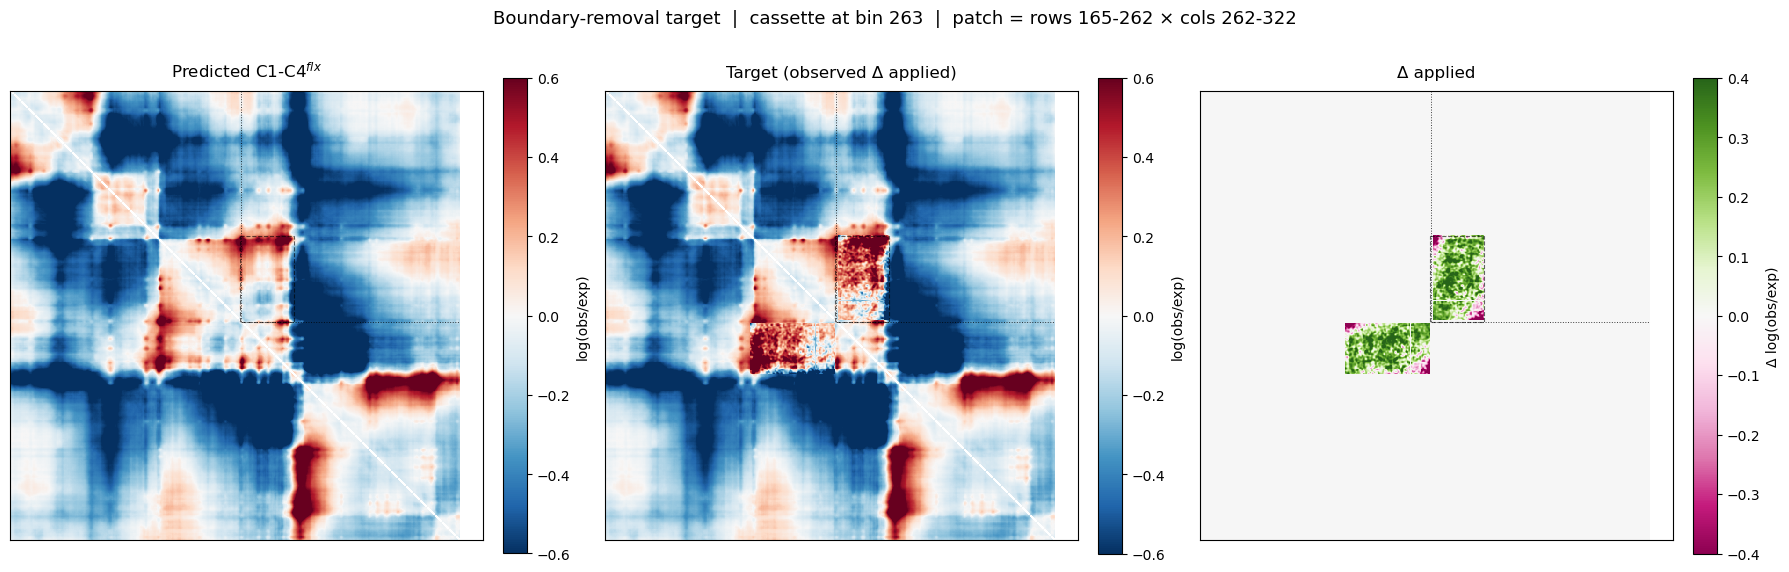

In [11]:
B_CASSETTE = 263

VABS, VDIFF = 0.6, 0.4
panels = [
    (preds["C1-C4flx"], "Predicted C1-C4$^{flx}$", "RdBu_r", VABS, "log(obs/exp)"),
    (target_map, "Target (observed Δ applied)", "RdBu_r", VABS, "log(obs/exp)"),
    (delta, "Δ applied", "PiYG", VDIFF, "Δ log(obs/exp)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
for ax, (mat, title, cmap, v, lab) in zip(axes, panels):
    im = ax.imshow(mat, cmap=cmap, vmin=-v, vmax=v, interpolation="none")
    ax.plot([B_CASSETTE, B_CASSETTE], [0, B_CASSETTE], "k:", lw=0.7, alpha=0.75)
    ax.plot([B_CASSETTE, mat.shape[0]], [B_CASSETTE, B_CASSETTE], "k:", lw=0.7, alpha=0.75)
    ax.add_patch(
        plt.Rectangle(
            (col_lo, row_lo),
            col_hi - col_lo,
            row_hi - row_lo,
            fill=False,
            ec="k",
            lw=0.8,
            ls="--",
            alpha=0.6,
        )
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=lab)

fig.suptitle(
    f"Boundary-removal target  |  cassette at bin {B_CASSETTE}  |  "
    f"patch = rows {row_lo}-{row_hi - 1} × cols {col_lo}-{col_hi - 1}",
    fontsize=13,
    y=1.00,
)
plt.tight_layout()

# fig.savefig(
#     PLOTS_DIR / "boundary_removal_target_overview.png",
#     dpi=300,
#     bbox_inches="tight",
# )
plt.show()
plt.close(fig)

saved pred_flx_tad  ((159, 159), ±1.0)


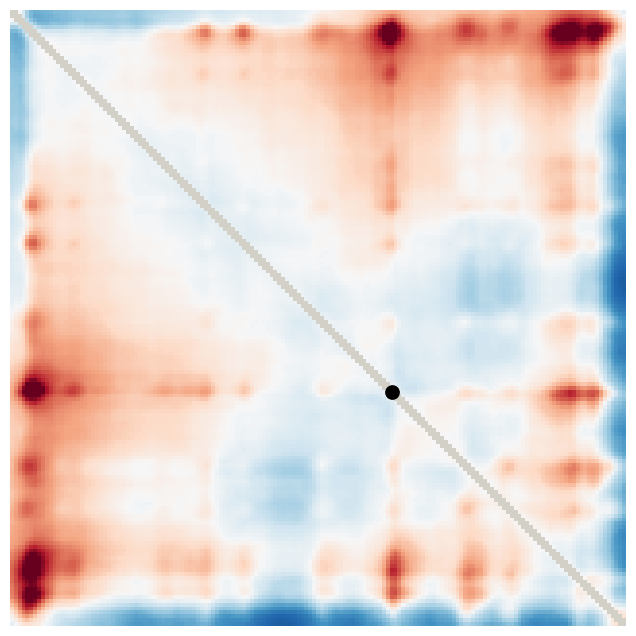

saved pred_target_tad  ((159, 159), ±1.0)


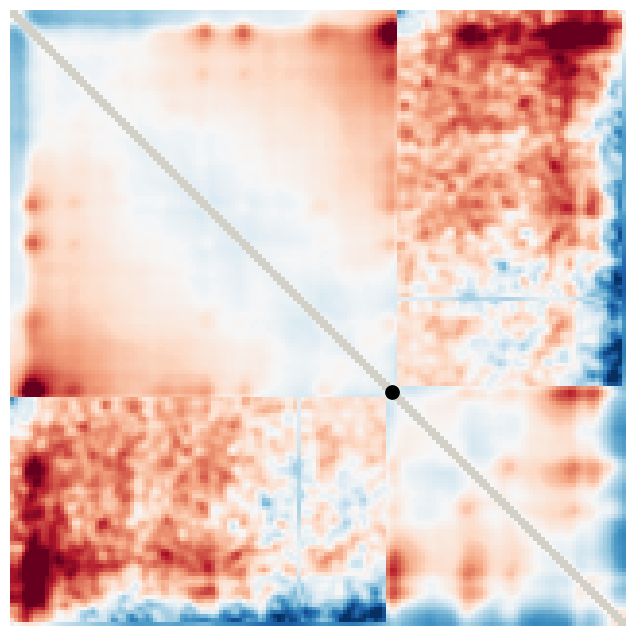

In [12]:
import copy

TAD_LO, TAD_HI = 165, 323
sl = slice(TAD_LO, TAD_HI + 1)
B_REL = B_CASSETTE - TAD_LO

GRAY = "#d3d1c7"
cmap_abs = copy.copy(plt.get_cmap("RdBu_r"))
cmap_abs.set_bad(GRAY)

for stem, mat in [
    ("pred_flx_tad", preds["C1-C4flx"][sl, sl]),
    ("pred_target_tad", target_map[sl, sl]),
]:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(
        mat.astype(np.float32),
        cmap=cmap_abs,
        vmin=-1.0,
        vmax=1.0,
        interpolation="none",
    )
    ax.plot(
        B_REL,
        B_REL,
        marker="o",
        ms=9,
        mfc="k",
        mec="k",
        mew=1.6,
        zorder=5,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # fig.savefig(
    #     PLOTS_DIR / f"{stem}.svg",
    #     format="svg",
    #     bbox_inches="tight",
    #     pad_inches=0.02,
    # )
    print(f"saved {stem}  ({mat.shape}, ±1.0)")
    plt.show()
    plt.close(fig)

## Save the target vector used by optimization

In [13]:
target_vector = upper_triangular_to_vector(target_map, DIAG_OFFSET)
target_tensor = torch.tensor(target_vector).to(device)
# torch.save(target_tensor, DATA_DIR / "target_cassette_boundary_lost.pt")

print(f"Saved target vector: {DATA_DIR / 'target_cassette_boundary_lost.pt'}")

Saved target vector: data/target_cassette_boundary_lost.pt
